In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/train.csv')

df.shape        


Matplotlib is building the font cache; this may take a moment.


(891, 12)

In [2]:
df.head(10)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)
print('Пропусков в %:')
print(missing_pct[missing_pct > 0])


Пропусков в %:
Cabin       77.104377
Age         19.865320
Embarked     0.224467
dtype: float64


In [7]:
df['Survived'].value_counts(normalize=True)
# 0 (погиб)    61.6%
# 1 (выжил)    38.4%

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

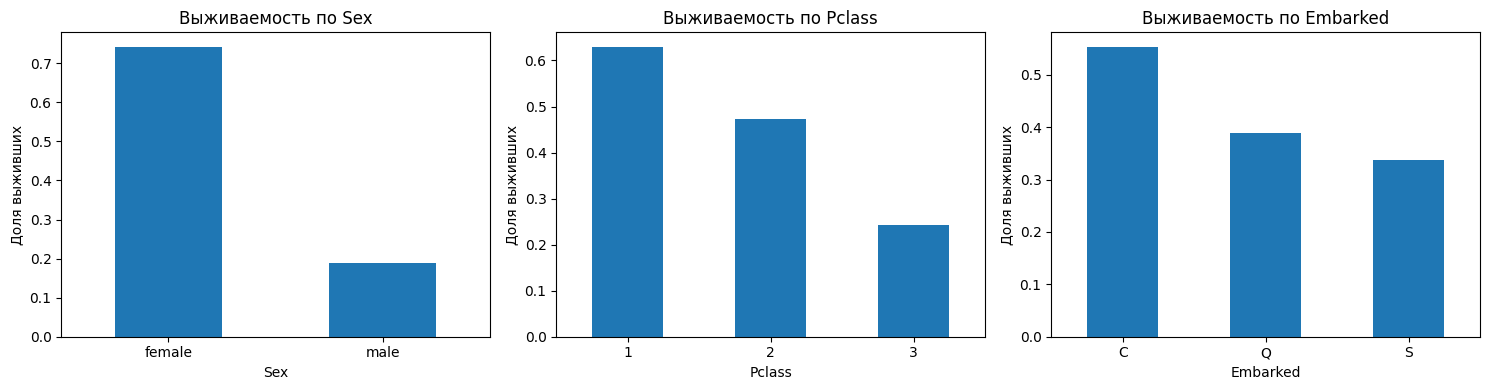

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['Sex', 'Pclass', 'Embarked']):
    df.groupby(col)['Survived'].mean().plot(kind='bar', ax=ax)
    ax.set_title(f'Выживаемость по {col}')
    ax.set_ylabel('Доля выживших')
    ax.tick_params(rotation=0)

plt.tight_layout()
plt.show()

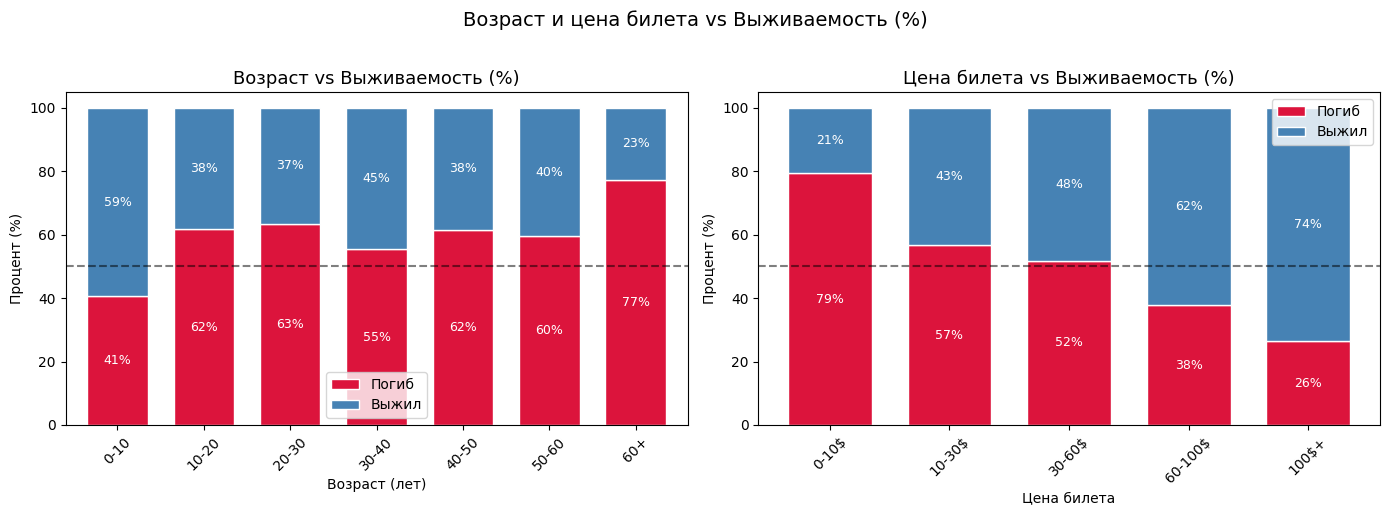

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- График 1: Возраст (проценты) ---
bins = [0, 10, 20, 30, 40, 50, 60, 80]
labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60+']
df['Age_bin'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_survival = df.groupby(
    ['Age_bin', 'Survived'],
    observed=True
).size().unstack()
age_survival.columns = ['Погиб', 'Выжил']

# Нормализуем по строкам = каждая группа 100%:
age_survival_pct = age_survival.div(
    age_survival.sum(axis=1), axis=0
) * 100

age_survival_pct.plot(
    kind='bar',
    ax=axes[0],
    color=['crimson', 'steelblue'],
    width=0.7,
    edgecolor='white',
    stacked=True  # ← стопка до 100%!
)
axes[0].set_title('Возраст vs Выживаемость (%)', fontsize=13)
axes[0].set_xlabel('Возраст (лет)')
axes[0].set_ylabel('Процент (%)')
axes[0].legend(['Погиб', 'Выжил'])
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=50, color='black',
                linestyle='--', alpha=0.5)  # линия 50%

# Добавляем % на столбики:
for i, (idx, row) in enumerate(age_survival_pct.iterrows()):
    axes[0].text(
        i, row['Погиб'] / 2,
        f"{row['Погиб']:.0f}%",
        ha='center', va='center',
        color='white', fontsize=9
    )
    axes[0].text(
        i, row['Погиб'] + row['Выжил'] / 2,
        f"{row['Выжил']:.0f}%",
        ha='center', va='center',
        color='white', fontsize=9
    )

# --- График 2: Цена билета (проценты) ---
fare_bins = [0, 10, 30, 60, 100, 600]
fare_labels = ['0-10$', '10-30$', '30-60$', '60-100$', '100$+']
df['Fare_bin'] = pd.cut(df['Fare'], bins=fare_bins, labels=fare_labels)

fare_survival = df.groupby(
    ['Fare_bin', 'Survived'],
    observed=True
).size().unstack()
fare_survival.columns = ['Погиб', 'Выжил']

# Нормализуем:
fare_survival_pct = fare_survival.div(
    fare_survival.sum(axis=1), axis=0
) * 100

fare_survival_pct.plot(
    kind='bar',
    ax=axes[1],
    color=['crimson', 'steelblue'],
    width=0.7,
    edgecolor='white',
    stacked=True
)
axes[1].set_title('Цена билета vs Выживаемость (%)', fontsize=13)
axes[1].set_xlabel('Цена билета')
axes[1].set_ylabel('Процент (%)')
axes[1].legend(['Погиб', 'Выжил'])
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=50, color='black',
                linestyle='--', alpha=0.5)

# Добавляем % на столбики:
for i, (idx, row) in enumerate(fare_survival_pct.iterrows()):
    axes[1].text(
        i, row['Погиб'] / 2,
        f"{row['Погиб']:.0f}%",
        ha='center', va='center',
        color='white', fontsize=9
    )
    axes[1].text(
        i, row['Погиб'] + row['Выжил'] / 2,
        f"{row['Выжил']:.0f}%",
        ha='center', va='center',
        color='white', fontsize=9
    )

plt.suptitle(
    'Возраст и цена билета vs Выживаемость (%)',
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

# Удаляем временные колонки:
df.drop(columns=['Age_bin', 'Fare_bin'], inplace=True)

Text(0.5, 1.0, 'Выживаемость: пол × класс')

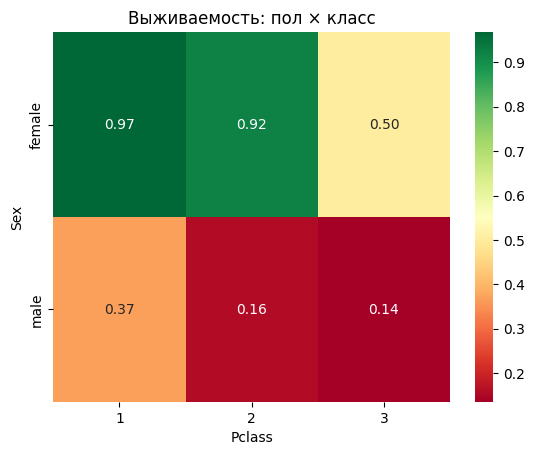

In [12]:
# Выживаемость: пол + класс вместе
pivot = df.pivot_table('Survived',
                        index='Sex',
                        columns='Pclass',
                        aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn')
plt.title('Выживаемость: пол × класс')

Text(0.5, 1.0, 'Корреляционная матрица')

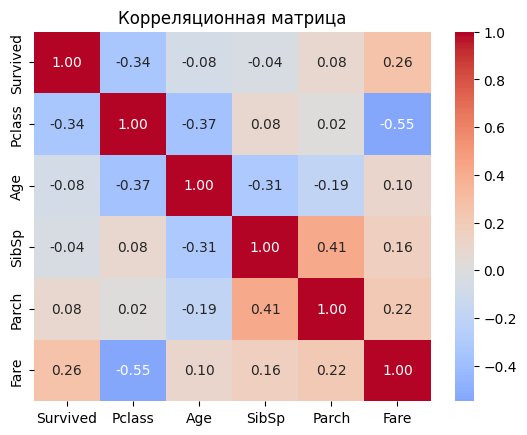

In [13]:
# Только числовые столбцы
corr = df[['Survived','Pclass','Age','SibSp','Parch','Fare']].corr()
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Корреляционная матрица')

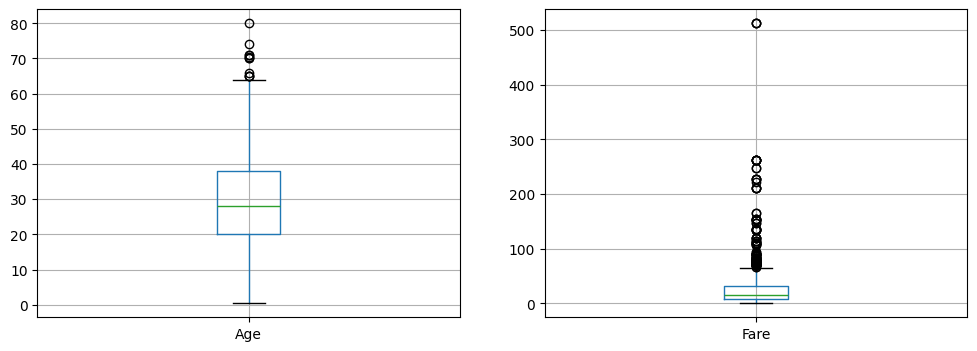

,Name,Fare,Pclass,Survived
258,"Ward, Miss. Anna",512.3292,1,1
679,"Cardeza, Mr. Thomas Drake Martinez",512.3292,1,1
737,"Lesurer, Mr. Gustave J",512.3292,1,1


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.boxplot(column='Age', ax=axes[0])
df.boxplot(column='Fare', ax=axes[1])
plt.show()

# Самые дорогие билеты
df[df['Fare'] > 300][['Name','Fare','Pclass','Survived']]

In [16]:
# Добавь перед графиком:
df['Deck'] = df['Cabin'].str.extract(r'([A-Za-z])')
df['Deck'] = df['Deck'].fillna('Unknown')
df['Has_Cabin'] = df['Cabin'].notna().astype(int)

print(df['Deck'].value_counts())

Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64


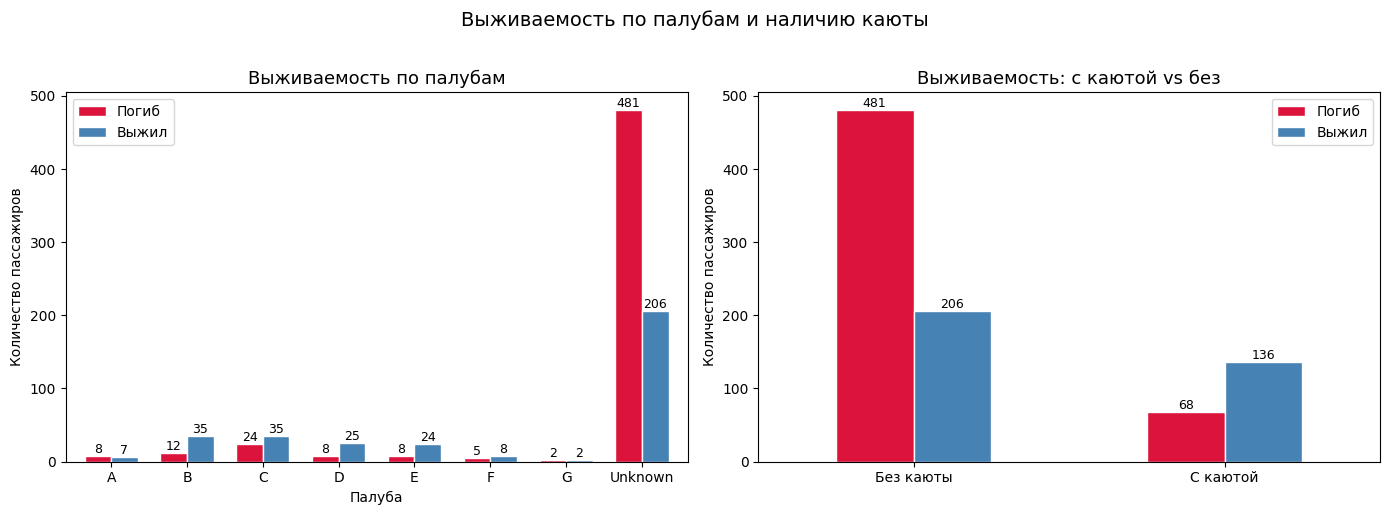

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- График 1: Выживаемость по палубам ---
deck_survival = df.groupby(
    ['Deck', 'Survived'],
    observed=True
).size().unstack()
deck_survival.columns = ['Погиб', 'Выжил']

# Сортируем по алфавиту:
deck_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'Unknown']
deck_survival = deck_survival.reindex(deck_order)

deck_survival.plot(
    kind='bar',
    ax=axes[0],
    color=['crimson', 'steelblue'],
    width=0.7,
    edgecolor='white'
)
axes[0].set_title('Выживаемость по палубам', fontsize=13)
axes[0].set_xlabel('Палуба')
axes[0].set_ylabel('Количество пассажиров')
axes[0].legend(['Погиб', 'Выжил'])
axes[0].tick_params(axis='x', rotation=0)

# --- График 2: Выживаемость с каютой и без ---
cabin_survival = df.groupby(
    ['Has_Cabin', 'Survived'],
    observed=True
).size().unstack()
cabin_survival.columns = ['Погиб', 'Выжил']
cabin_survival.index = ['Без каюты', 'С каютой']

cabin_survival.plot(
    kind='bar',
    ax=axes[1],
    color=['crimson', 'steelblue'],
    width=0.5,
    edgecolor='white'
)
axes[1].set_title('Выживаемость: с каютой vs без', fontsize=13)
axes[1].set_xlabel('')
axes[1].set_ylabel('Количество пассажиров')
axes[1].legend(['Погиб', 'Выжил'])
axes[1].tick_params(axis='x', rotation=0)

# Добавим цифры на столбики:
for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fontsize=9)

plt.suptitle('Выживаемость по палубам и наличию каюты',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [18]:
# ============================================
# Анализ: класс vs наличие каюты
# ============================================

# Кросс-таблица: класс vs наличие каюты
cabin_class = pd.crosstab(
    df['Pclass'],
    df['Has_Cabin'],
    margins=True
)
cabin_class.columns = ['Без каюты', 'С каютой', 'Всего']
cabin_class.index = ['1й класс', '2й класс', '3й класс', 'Всего']
print("=== КЛАСС vs НАЛИЧИЕ КАЮТЫ ===")
print(cabin_class)

print("\n=== ПРОЦЕНТ С КАЮТОЙ ПО КЛАССАМ ===")
cabin_class_pct = pd.crosstab(
    df['Pclass'],
    df['Has_Cabin'],
    normalize='index'
) * 100
cabin_class_pct.columns = ['Без каюты %', 'С каютой %']
cabin_class_pct.index = ['1й класс', '2й класс', '3й класс']
print(cabin_class_pct.round(1))

=== КЛАСС vs НАЛИЧИЕ КАЮТЫ ===
          Без каюты  С каютой  Всего
1й класс         40       176    216
2й класс        168        16    184
3й класс        479        12    491
Всего           687       204    891

=== ПРОЦЕНТ С КАЮТОЙ ПО КЛАССАМ ===
          Без каюты %  С каютой %
1й класс         18.5        81.5
2й класс         91.3         8.7
3й класс         97.6         2.4


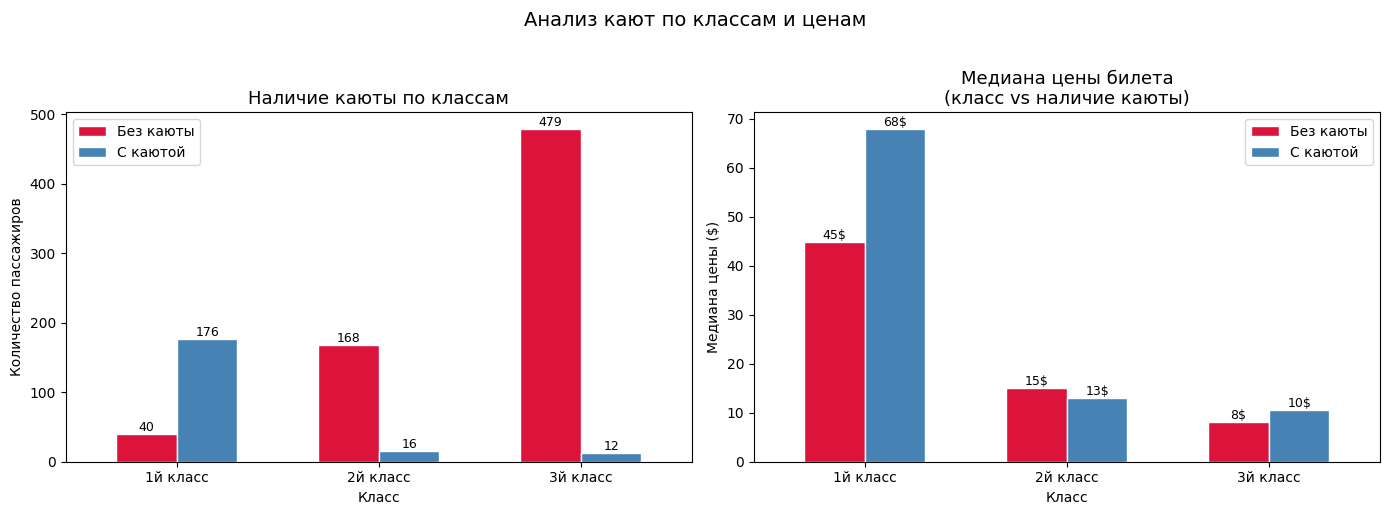

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Абсолютные числа
cabin_class_plot = pd.crosstab(df['Pclass'], df['Has_Cabin'])
cabin_class_plot.columns = ['Без каюты', 'С каютой']
cabin_class_plot.index = ['1й класс', '2й класс', '3й класс']

cabin_class_plot.plot(
    kind='bar',
    ax=axes[0],
    color=['crimson', 'steelblue'],
    width=0.6,
    edgecolor='white'
)
axes[0].set_title('Наличие каюты по классам', fontsize=13)
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Количество пассажиров')
axes[0].tick_params(axis='x', rotation=0)
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=9)

# График 2: Медиана цены билета
fare_deck = df.groupby(['Pclass', 'Has_Cabin'])['Fare'].median().unstack()
fare_deck.columns = ['Без каюты', 'С каютой']
fare_deck.index = ['1й класс', '2й класс', '3й класс']

fare_deck.plot(
    kind='bar',
    ax=axes[1],
    color=['crimson', 'steelblue'],
    width=0.6,
    edgecolor='white'
)
axes[1].set_title('Медиана цены билета\n(класс vs наличие каюты)', fontsize=13)
axes[1].set_xlabel('Класс')
axes[1].set_ylabel('Медиана цены ($)')
axes[1].tick_params(axis='x', rotation=0)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.0f$', fontsize=9)

plt.suptitle('Анализ кают по классам и ценам', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

KeyError: 'Погяб'

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


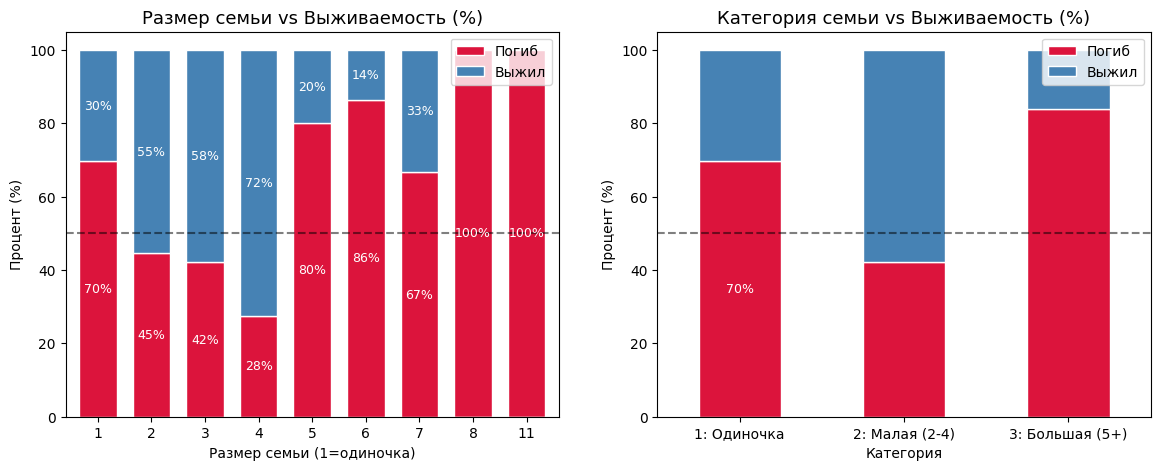

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- График 1: Выживаемость по размеру семьи (%) ---
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

family_survival = df.groupby(
    ['FamilySize', 'Survived'],
    observed=True
).size().unstack()
family_survival.columns = ['Погиб', 'Выжил']

# Нормализуем:
family_pct = family_survival.div(
    family_survival.sum(axis=1), axis=0
) * 100

family_pct.plot(
    kind='bar',
    ax=axes[0],
    color=['crimson', 'steelblue'],
    width=0.7,
    edgecolor='white',
    stacked=True
)
axes[0].set_title('Размер семьи vs Выживаемость (%)', fontsize=13)
axes[0].set_xlabel('Размер семьи (1=одиночка)')
axes[0].set_ylabel('Процент (%)')
axes[0].legend(['Погиб', 'Выжил'])
axes[0].tick_params(axis='x', rotation=0)
axes[0].axhline(y=50, color='black',
                linestyle='--', alpha=0.5)

# Проценты на столбики:
for i, (idx, row) in enumerate(family_pct.iterrows()):
    axes[0].text(
        i, row['Погиб'] / 2,
        f"{row['Погиб']:.0f}%",
        ha='center', va='center',
        color='white', fontsize=9
    )
    axes[0].text(
        i, row['Погиб'] + row['Выжил'] / 2,
        f"{row['Выжил']:.0f}%",
        ha='center', va='center',
        color='white', fontsize=9
    )

# --- График 2: Категория семьи (%) ---
def family_category(size):
    if size == 1:
        return '1: Одиночка'
    elif size <= 4:
        return '2: Малая (2-4)'
    else:
        return '3: Большая (5+)'

df['Family_Cat'] = df['FamilySize'].apply(family_category)

cat_survival = df.groupby(
    ['Family_Cat', 'Survived'],
    observed=True
).size().unstack()
cat_survival.columns = ['Погиб', 'Выжил']

cat_pct = cat_survival.div(
    cat_survival.sum(axis=1), axis=0
) * 100

cat_pct.plot(
    kind='bar',
    ax=axes[1],
    color=['crimson', 'steelblue'],
    width=0.5,
    edgecolor='white',
    stacked=True
)
axes[1].set_title('Категория семьи vs Выживаемость (%)', fontsize=13)
axes[1].set_xlabel('Категория')
axes[1].set_ylabel('Процент (%)')
axes[1].legend(['Погиб', 'Выжил'])
axes[1].tick_params(axis='x', rotation=0)
axes[1].axhline(y=50, color='black',
                linestyle='--', alpha=0.5)

# Проценты на столбики:
for i, (idx, row) in enumerate(cat_pct.iterrows()):
    axes[1].text(
        i, row['Погиб'] / 2,
        f"{row['Погиб']:.0f}%",
        ha='center', va='center',
        color='white', fontsize=9
    )
    axes[1].text(
        i, row['Погяб'] + row['Выжил'] / 2,
        f"{row['Выжил']:.0f}%",
        ha='center', va='center',
        color='white', fontsize=9
    )

plt.suptitle('Размер семьи vs Выживаемость', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Удаляем временные колонки:
df.drop(columns=['Family_Cat'], inplace=True)

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


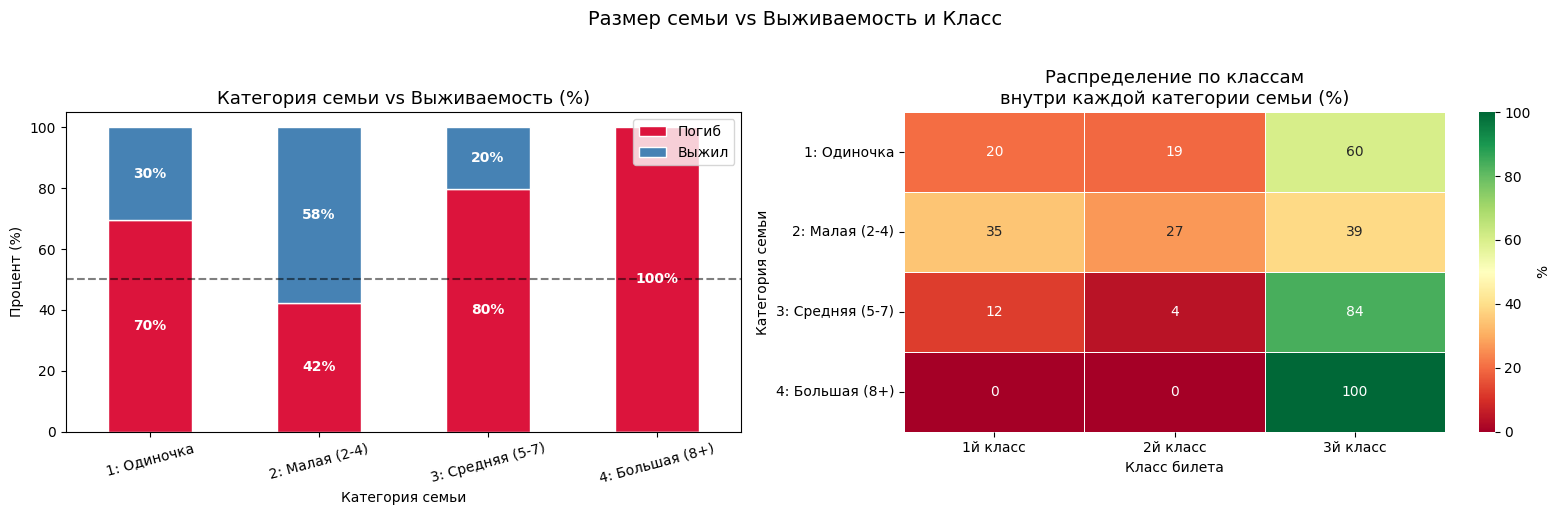

=== АБСОЛЮТНЫЕ ЧИСЛА ПО КАТЕГОРИЯМ ===
                  Погиб  Выжил
Family_Cat                    
1: Одиночка       374.0  163.0
2: Малая (2-4)    123.0  169.0
3: Средняя (5-7)   39.0   10.0
4: Большая (8+)    13.0    NaN

=== ПРОЦЕНТ ВЫЖИВШИХ ===
Family_Cat
1: Одиночка         30.4
2: Малая (2-4)      57.9
3: Средняя (5-7)    20.4
4: Большая (8+)      NaN
Name: Выжил, dtype: float64


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Создаём категории семьи:
def family_category(size):
    if size == 1:
        return '1: Одиночка'
    elif size <= 4:
        return '2: Малая (2-4)'
    elif size <= 7:
        return '3: Средняя (5-7)'
    else:
        return '4: Большая (8+)'

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['Family_Cat'] = df['FamilySize'].apply(family_category)

# ============================================
# График 1: Семья vs Выживаемость (%)
# ============================================
cat_survival = df.groupby(
    ['Family_Cat', 'Survived'],
    observed=True
).size().unstack()
cat_survival.columns = ['Погиб', 'Выжил']

cat_pct = cat_survival.div(
    cat_survival.sum(axis=1), axis=0
) * 100

cat_pct.plot(
    kind='bar',
    ax=axes[0],
    color=['crimson', 'steelblue'],
    width=0.5,
    edgecolor='white',
    stacked=True
)
axes[0].set_title('Категория семьи vs Выживаемость (%)',
                  fontsize=13)
axes[0].set_xlabel('Категория семьи')
axes[0].set_ylabel('Процент (%)')
axes[0].legend(['Погиб', 'Выжил'])
axes[0].tick_params(axis='x', rotation=15)
axes[0].axhline(y=50, color='black',
                linestyle='--', alpha=0.5)

# Проценты на столбики:
for i, (idx, row) in enumerate(cat_pct.iterrows()):
    axes[0].text(
        i, row['Погиб'] / 2,
        f"{row['Погиб']:.0f}%",
        ha='center', va='center',
        color='white', fontsize=10, fontweight='bold'
    )
    axes[0].text(
        i, row['Погиб'] + row['Выжил'] / 2,
        f"{row['Выжил']:.0f}%",
        ha='center', va='center',
        color='white', fontsize=10, fontweight='bold'
    )

# ============================================
# График 2: Семья + Класс (тепловая карта)
# ============================================
# Кросс-таблица: категория семьи vs класс
family_class = pd.crosstab(
    df['Family_Cat'],
    df['Pclass'],
    normalize='index'  # проценты по строкам
) * 100

family_class.columns = ['1й класс', '2й класс', '3й класс']

sns.heatmap(
    family_class,
    ax=axes[1],
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': '%'}
)
axes[1].set_title('Распределение по классам\nвнутри каждой категории семьи (%)',
                  fontsize=13)
axes[1].set_xlabel('Класс билета')
axes[1].set_ylabel('Категория семьи')
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Размер семьи vs Выживаемость и Класс',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Дополнительная таблица:
print("=== АБСОЛЮТНЫЕ ЧИСЛА ПО КАТЕГОРИЯМ ===")
print(cat_survival)
print(f"\n=== ПРОЦЕНТ ВЫЖИВШИХ ===")
print(cat_pct['Выжил'].round(1))

# Удаляем временные колонки:
df.drop(columns=['Family_Cat'], inplace=True)

## 🎯 Главный обобщающий вывод

Выживаемость на Титанике определялась
тремя главными факторами:

### 1. КТО ТЫ
`Пол + Возраст + Титул`  
→ социальный приоритет при эвакуации

### 2. СКОЛЬКО У ТЕБЯ ДЕНЕГ
`Pclass + Fare + Has_Cabin`  
→ физическое расположение на корабле  
→ близость к шлюпкам

### 3. С КЕМ ТЫ
`FamilySize`  
→ малая семья **помогает**  
→ большая семья **мешает**

---

> **Оставшиеся ~17% ошибок модели =**  
> необъяснимая случайность  
> реального трагического события